# Next-day sales for discounted perishables

**Should a category manager discount a perishable product tomorrow?** This notebook builds and compares models that predict next-day sales for a store-product given tomorrow's discount, so that the question can eventually be answered by feeding candidate discounts into the best model (phase 2).

It is written to be read top to bottom. Each section states what was done, shows the numbers, and records the decision taken and why. The code that does the work lives in the small package under `src/finalproject_pricingml/`; the cells here only call it, so the story stays readable.

| Section | What it covers |
|---|---|
| 1–2 | Goal and data |
| 3–7 | Series selection, features, splits, metrics, baseline |
| 8 | k-nearest neighbours: tuning, locked design |
| 9 | Random forest: tuning, locked design |
| 10–11 | CatBoost and a forest + CatBoost ensemble (next models to test) |
| 12 | Comparison on the validation weeks and the unseen test week |
| 13–14 | Findings, limits, next steps |

In [1]:
import pandas as pd
from IPython.display import display

from finalproject_pricingml import config as C, data, evaluate as ev, models, plots

# Set to True to recompute every tuning grid from the feature table (about a minute in total).
# When False, the grids are read back from results/ and only the final test-week models are fitted.
RERUN_TUNING = False

pd.set_option("display.precision", 4)
pd.set_option("display.width", 140)

## 1. Goal

Help a Dingdong category manager decide whether to discount a perishable product tomorrow, by predicting next-day sales for a store-product given tomorrow's discount.

- **Success test:** lower next-day sales error than a simple baseline.
- **Phase 2 (after the best model is chosen):** feed candidate discount rates into the model to suggest a discount. This is a model-based claim, not something the data can verify.

Two limits set by the data:

- The dataset has one discount rate per day, with no intraday markdown. "End-of-day discount" therefore means "tomorrow's daily discount".
- Discounts were not assigned at random, so the model's response to discount is a correlation, not a proven cause.

## 2. Data

Source: [FreshRetailNet-50K](https://huggingface.co/datasets/Dingdong-Inc/FreshRetailNet-50K) (Dingdong, Hugging Face, CC BY 4.0). The two parquet files are not in the repository; put them in `data/raw/` (see the README).

| Item | Value |
|---|---|
| Series (store-product) | 50,000 |
| Stores / cities / products | 898 / 18 / 865 |
| Training period | 90 days, 2024-03-28 to 2024-06-25 (`train.parquet`) |
| Unseen test period | 7 days, 2024-06-26 to 2024-07-02 (`eval.parquet`) |
| Missing values | None |
| Rows with no discount (exactly 1.0) | About 48% |
| Rows with at least one stockout hour | 44% |

- `sale_amount` is normalised, not real units, so errors only mean something relative to a baseline.
- Stockouts mean recorded sales understate true demand on those days. Stockout days were kept.

## 3. Store and product selection

The model needs series where the discount actually varies. A day counts as "discounted" when the discount is below 0.95. A series is usable when:

- it is discounted on 15–85% of days (removes never- and always-discounted products),
- it switches between discounted and not at least 6 times,
- it has zero sales on fewer than 20% of days.

Across the full dataset, 4,997 series are never discounted, 1,872 are always discounted, and 16,684 of 50,000 pass. To keep the first models small the working set is the five stores with the most usable series, all in city 0. (`data.select_series` scores every series; the result is cached in `data/processed/selected_series.csv`.)

In [2]:
feat = data.load_features()  # builds data/processed/ from the raw parquet files on first use
selected = pd.read_csv(C.PROCESSED / "selected_series.csv")

stores = selected.groupby("store_id").agg(city=("city_id", "first"), usable_series=("product_id", "size"))
display(stores.sort_values("usable_series", ascending=False))
print(f"Working set: {len(selected)} series, {selected.product_id.nunique()} products, {len(feat):,} rows after building features")

,city,usable_series
store_id,,
18,0,64
343,0,64
235,0,63
182,0,61
154,0,60


Working set: 312 series, 122 products, 28,080 rows after building features


## 4. Does discount carry signal?

Before modelling: do deeper discounts go with higher sales in these series? Sales are expressed relative to each series' own average so that products of different size can be pooled.

In [3]:
rel = feat.assign(relative_sales=feat[C.TARGET] / feat.groupby(C.KEY)[C.TARGET].transform("mean"))
bands = pd.cut(rel.discount_next, [0, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0],
               labels=["below 0.6", "0.6–0.7", "0.7–0.8", "0.8–0.9", "0.9–0.95", "0.95–1.0 (none)"])
display(rel.groupby(bands, observed=True).agg(rows=("relative_sales", "size"), relative_sales=("relative_sales", "mean")).round(2))

,rows,relative_sales
discount_next,,
below 0.6,203,3.00
0.6–0.7,862,1.50
0.7–0.8,1980,1.35
0.8–0.9,5889,1.13
0.9–0.95,3646,1.03
0.95–1.0 (none),15500,0.84


Sales rise steadily as the discount deepens. Tomorrow's discount is worth modelling.

## 5. Target and features

**Target:** sales on day t+1 for the same store and product. One row is one store-product-day. Every feature is known on the evening of day t, when the discount decision is made.

**Why history features are needed.** The raw columns describe the day, not the product. kNN with raw columns only scored MAE 0.558 against a baseline of 0.339 in an early check; adding the product's own sales history brought it to 0.364.

**Locked feature set (10):**

| Feature | Column | Day |
|---|---|---|
| Sales | `sales_t` | t |
| Sales 7 days before the target day | `sales_lag7` | t−6 |
| Mean sales over the last 7 days | `sales_mean7` | up to t |
| Mean sales to date | `sales_mean_to_date` | up to t |
| Stockout hours | `stockout_hours_t` | t |
| Discount | `discount_t` | t |
| Discount (the manager's decision) | `discount_next` | t+1 |
| Activity flag | `activity_t` | t |
| Holiday flag | `holiday_next` | t+1 |
| Weekday | `weekday_next` | t+1 |

**Considered and left out:**

| Item | Reason |
|---|---|
| Weather on day t (rain, temperature, humidity) | Removing it lowered error for both kNN and the forest (sections 8 and 9) |
| Weather on day t+1 | No gain; 0.88–0.97 correlated with day t |
| Activity flag on day t+1 | No gain; largely repeats tomorrow's discount (92% of activity days are discounted) |
| Stockout hours on day t+1 | Not known in advance; would leak the answer |
| Hourly sales and stock lists, product ids | Excluded from the first models by design |

In [4]:
display(feat[C.ROW_KEY + C.FEATURES + [C.TARGET]].head())
display(feat[C.FEATURES + [C.TARGET]].describe().T[["mean", "std", "min", "max"]].round(2))

,store_id,product_id,dt,sales_t,sales_lag7,sales_mean7,sales_mean_to_date,stockout_hours_t,discount_t,discount_next,activity_t,holiday_next,weekday_next,target_sales
0,18,11,2024-04-04,0.2,0.9,0.9000,0.9000,0.0,0.833,0.833,1.0,1,3,1.2
1,18,11,2024-04-05,1.2,0.6,0.9429,0.9375,7.0,0.833,0.833,1.0,1,4,0.9
2,18,11,2024-04-06,0.9,1.7,0.9857,0.9333,0.0,0.833,0.833,1.0,1,5,1.3
3,18,11,2024-04-07,1.3,1.5,0.9286,0.9700,8.0,0.833,0.833,1.0,0,6,1.2
4,18,11,2024-04-08,1.2,0.5,0.8857,0.9909,8.0,0.833,0.833,1.0,0,0,1.1


,mean,std,min,max
sales_t,0.88,0.83,0.00,10.60
sales_lag7,0.86,0.79,0.00,10.20
sales_mean7,0.87,0.68,0.00,7.47
sales_mean_to_date,0.79,0.50,0.07,3.81
stockout_hours_t,3.23,4.43,0.00,16.00
discount_t,0.93,0.10,0.26,1.00
discount_next,0.93,0.10,0.26,1.00
activity_t,0.40,0.49,0.00,1.00
holiday_next,0.34,0.48,0.00,1.00
weekday_next,3.01,2.01,0.00,6.00


## 6. Cleaning and splits

- No duplicate store-product-days, no date gaps, no missing values in the 312 series (asserted in `data.build_features`).
- Days with a discount of exactly 0 are treated as give-aways or data artefacts: their sales are blanked so they never feed a lag or a target.
- The first 7 days of each series are dropped because the 7-day features need a full week.
- Standardization (where a model needs it) is fitted on the training rows of each fold only.

Splits are by time. For each validation week the model trains on every row dated before that week. The test week comes from `eval.parquet` and is touched exactly once per model, after its design is locked.

In [5]:
display(data.split_summary(feat))

rows  first_day   last_day
split val_fold                             
test  0          2184 2024-06-26 2024-07-02
train 0         14976 2024-04-04 2024-05-21
      1          2184 2024-05-22 2024-05-28
      2          2184 2024-05-29 2024-06-04
      3          2184 2024-06-05 2024-06-11
      4          2184 2024-06-12 2024-06-18
      5          2184 2024-06-19 2024-06-25

**Why not random splits.** Neighbouring days of the same product share most of their history, so random splits put near-copies on both sides and flatter the model. Mean kNN MAE over five rounds, all 13 original features (one-off check, not scripted):

| k | Time-ordered | Random, no overlap | Random with replacement |
|---|---|---|---|
| 1 | 0.429 | 0.377 | 0.139 |
| 5 | 0.342 | 0.303 | 0.261 |
| 15 | 0.327 | 0.294 | 0.280 |
| 40 | 0.327 | 0.296 | 0.291 |

Random splits also pick the wrong k: k=1 looks best with replacement and is worst in honest testing. Every result below uses the time-ordered folds.

## 7. Metrics and baseline

- **MAE:** average absolute error, in sales units. Main tuning criterion.
- **WAPE:** total absolute error divided by total sales.
- **MSE:** reported as the academic metric. It penalises large misses more heavily.

Baseline: the mean of the last 7 days' sales. It beats "same weekday last week" on every fold, so it is the bar every model has to clear.

In [6]:
train = ev.training_rows(feat)
baseline = ev.baseline_by_fold(train)
same_weekday = ev.baseline_by_fold(train, column="sales_lag7")

by_week = pd.DataFrame({"7-day average": baseline.mae, "Same weekday last week": same_weekday.mae}).rename(index=C.FOLD_LABELS)
by_week.loc["Average"] = by_week.mean()
display(by_week.round(3))

,7-day average,Same weekday last week
fold,,
May 22–28,0.309,0.385
May 29–Jun 4,0.316,0.387
Jun 5–11,0.362,0.446
Jun 12–18,0.327,0.435
Jun 19–25,0.328,0.422
Average,0.328,0.415


## 8. k-nearest neighbours

**How it works.** kNN stores the training rows. To predict a row it finds the k most similar training rows (Euclidean distance on standardized features) and averages their sales. There is no training step and no loss curve: k is a setting chosen by validation, not a parameter learned by gradient descent.

All figures below are average MAE over the five validation weeks.

### Round 1: neighbours and feature weighting, with weather (13 features)

A feature weight multiplies the standardized feature, so a weight of 2 makes it count twice as much in the distance. Three weightings were tried: equal weights, a *prior* weighting from expectations (sales averages, discounts, holiday, weekday ×2), and an *evidence-led* weighting (sales averages and tomorrow's discount ×2; weather and stockout ×0.5).

In [7]:
def best_per_weighting(path):
    s = pd.read_csv(path)
    s = s[s.k > 0]
    return s.loc[s.groupby("weighting").mae.idxmin()].set_index("weighting")[["k", "mae", "wape", "mse", "folds_beating_baseline"]]

round1 = best_per_weighting(C.RESULTS / "knn_stage1_with_weather_summary.csv")
round2 = best_per_weighting(C.RESULTS / "knn_stage1_three_weightings_summary.csv")
print(f"Baseline MAE: {baseline.mae.mean():.3f}\n")
print("Round 1, with weather (13 features): best k per weighting")
display(round1)

Baseline MAE: 0.328

Round 1, with weather (13 features): best k per weighting


,k,mae,wape,mse,folds_beating_baseline
weighting,,,,,
equal,25,0.3267,0.3426,0.2544,3
evidence,25,0.3115,0.3268,0.2294,5
prior,25,0.3182,0.3338,0.2407,5


An earlier prior that boosted weather and stockout hours made the model worse (0.332 at k=15 against 0.327 for equal weights). Weighting helped here, but the next round shows why.

### Round 2: weather removed (10 features)

In [8]:
print("Round 2, without weather (10 features): best k per weighting")
display(round2)
display(pd.DataFrame({"MAE with weather": round1.mae, "MAE without weather": round2.mae}).round(3))

Round 2, without weather (10 features): best k per weighting


,k,mae,wape,mse,folds_beating_baseline
weighting,,,,,
equal,25,0.3120,0.3273,0.2375,5
evidence,25,0.3088,0.3240,0.2293,5
prior,25,0.3114,0.3267,0.2362,5


,MAE with weather,MAE without weather
weighting,,
equal,0.327,0.312
evidence,0.311,0.309
prior,0.318,0.311


- Dropping weather mattered more than any weighting.
- Once weather is gone the three weightings are within 0.003, well inside the week-to-week variation (about 0.02). **Weighting was dropped.**
- Weather has no measurable link to the day's sales lift: correlation of about −0.01 with sales divided by the 7-day average.

### The k curve (10 features)

The final grid: eight values of k, equal weights against one last weighting (sales on day t ×2). `ev.cross_validate` fits each setting on the rows before each validation week and scores that week.

k,3,5,10,15,25,40,60,100
weighting,,,,,,,,
equal,0.3468,0.3298,0.3188,0.3139,0.3120,0.3123,0.3133,0.3157
sales_t,0.3491,0.3322,0.3194,0.3156,0.3125,0.3124,0.3137,0.3167


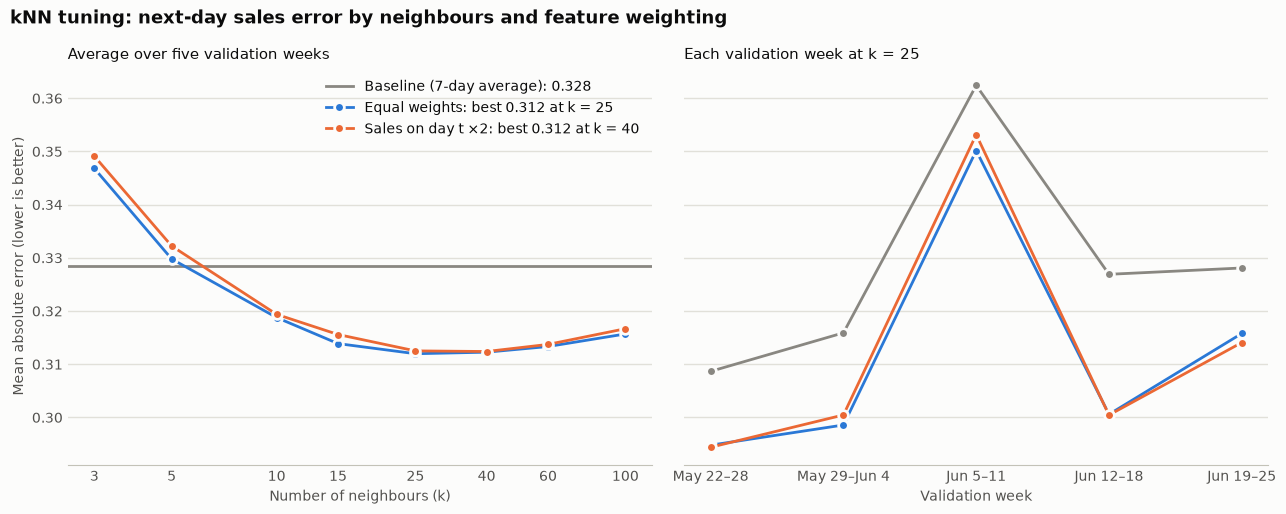

In [9]:
KNN_WEIGHTINGS = {"equal": {}, "sales_t": {"sales_t": 2}}
KNN_GRID = [{"weighting": w, "k": k} for w in KNN_WEIGHTINGS for k in (3, 5, 10, 15, 25, 40, 60, 100)]

if RERUN_TUNING:
    knn_folds = ev.cross_validate(feat, lambda weighting, k: models.make_knn(k, KNN_WEIGHTINGS[weighting]), KNN_GRID)
    knn_folds.to_csv(C.RESULTS / "knn_stage1_folds.csv", index=False)
else:
    knn_folds = pd.read_csv(C.RESULTS / "knn_stage1_folds.csv")
    knn_folds = knn_folds[knn_folds.k > 0]  # the file also holds the baseline rows

knn_summary = ev.summarise(knn_folds, ["weighting", "k"], baseline)
display(knn_summary.mae.unstack("weighting").round(4).T)

fig = plots.plot_knn_tuning(knn_folds, baseline, {"equal": ("Equal weights", C.COLOURS["knn"]), "sales_t": ("Sales on day t ×2", C.COLOURS["rf"])},
                            save=C.RESULTS / "knn_stage1.png")

Small k follows noise; large k averages over products that are too different. The bottom is flat from 15 to 60, and MSE also picks k=25.

### Further checks (one-off runs, k=25, change against 0.3120)

| Check | MAE | Change |
|---|---|---|
| Sales on day t at ×2 | 0.3125 | +0.0005 |
| Add activity t+1 and holiday t+1, both ×2 | 0.3129 | +0.0009 |
| Manhattan distance | 0.3105 | −0.0015 |
| Closer neighbours count more | 0.3115 | −0.0005 |
| Weekday as seven yes/no columns | 0.3174 | +0.0054 |
| Weekday removed | 0.3096 | −0.0024 |
| Min-max scaling | 0.3225 | +0.0105 |
| Robust scaling | 0.3103 | −0.0017 |
| Target = sales ÷ 7-day average, log-scaled features | 0.3079 | −0.0041 |
| Train on last 28 days only | 0.3156 | +0.0036 |

No option moved MAE by more than 0.004, so tuning stopped here.

### Which features carry the model (remove one at a time, k=25)

| Feature removed | Change in MAE |
|---|---|
| Discount on day t+1 | +0.0139 |
| 7-day average sales | +0.0095 |
| Sales on day t | +0.0082 |
| Average sales to date | +0.0024 |
| Discount on day t | +0.0007 |
| Sales 7 days before | +0.0004 |
| Holiday on day t+1 | +0.0001 |
| Stockout hours on day t | −0.0002 |
| Activity on day t | −0.0009 |
| Weekday of day t+1 | −0.0024 |

Tomorrow's discount is the most important single feature.

### Locked kNN design

- 10 features, standard scaling, Euclidean distance, all neighbours counted equally, **k = 25**.
- Validation: MAE 0.312, WAPE 32.7%, MSE 0.238, against baseline MAE 0.328, WAPE 34.5%, MSE 0.270. Ahead in all five weeks.

In [10]:
KNN_K = 25
knn_val = knn_folds[(knn_folds.weighting == "equal") & (knn_folds.k == KNN_K)].set_index("fold")
display(pd.DataFrame({"kNN": knn_val[["mae", "wape", "mse"]].mean(), "Baseline": baseline.mean()}).T.round(3))

,mae,wape,mse
kNN,0.312,0.327,0.237
Baseline,0.328,0.345,0.270


## 9. Random forest

**How it works.** A random forest builds many decision trees, each on a random sample of the training rows, and averages their predictions.

- **Split rule:** squared error. Each split is chosen to give the largest drop in the variance of sales in the two resulting groups. (Gini and entropy are the classification equivalents and do not apply to a continuous target.)
- **No scaling needed:** trees split on one feature at a time, so feature units do not matter.
- **No gradient descent:** trees are built by choosing splits directly, so there is no loss curve over training steps.
- **What limits over-fitting:** maximum depth and minimum rows per leaf. Either stops trees from memorising noise; they play the role k played for kNN.

All figures are average MAE over the five validation weeks, with 300 trees.

### Round 1: leaf size, features per split, weather (36 combinations, no depth limit)

In [11]:
round1_rf = pd.read_csv(C.RESULTS / "rf_tuning_leaf_features_summary.csv")
display(round1_rf.pivot_table(index=["features", "min_leaf"], columns="max_features", values="mae").round(4))
print("Combinations beating the baseline in all five weeks:", (round1_rf.folds_beating_baseline == 5).sum(), "of", len(round1_rf))

max_features             0.33    0.50    1.00
features     min_leaf                        
10 features  1         0.3057  0.3066  0.3122
             3         0.3039  0.3044  0.3089
             5         0.3037  0.3034  0.3068
             10        0.3044  0.3031  0.3050
             20        0.3064  0.3051  0.3060
             40        0.3095  0.3077  0.3085
with weather 1         0.3103  0.3116  0.3163
             3         0.3078  0.3079  0.3113
             5         0.3069  0.3062  0.3090
             10        0.3065  0.3058  0.3067
             20        0.3076  0.3067  0.3079
             40        0.3107  0.3088  0.3103

Combinations beating the baseline in all five weeks: 36 of 36


- Best setting: leaf ≥ 10, half the features per split, no weather: 0.3031. The same setting with weather: 0.3058.
- Weather made every setting worse, as it did for kNN, though by less (about 0.003 against about 0.015). **Weather stays out.**
- Every one of the 36 combinations beat the baseline in all five weeks: the forest is far less sensitive to its settings than kNN was.

### Round 2: depth and leaf size (16 combinations, half the features per split)

min_leaf,3,5,10,20
max_depth,,,,
10,0.3024,0.3027,0.3035,0.3052
15,0.3030,0.3031,0.3032,0.3049
20,0.3043,0.3036,0.3034,0.3048
No limit,0.3044,0.3034,0.3031,0.3051


min_leaf,3,5,10,20
max_depth,,,,
10,10,10,10,10
15,15,15,15,15
20,20,20,20,20
No limit,41,36,31,27


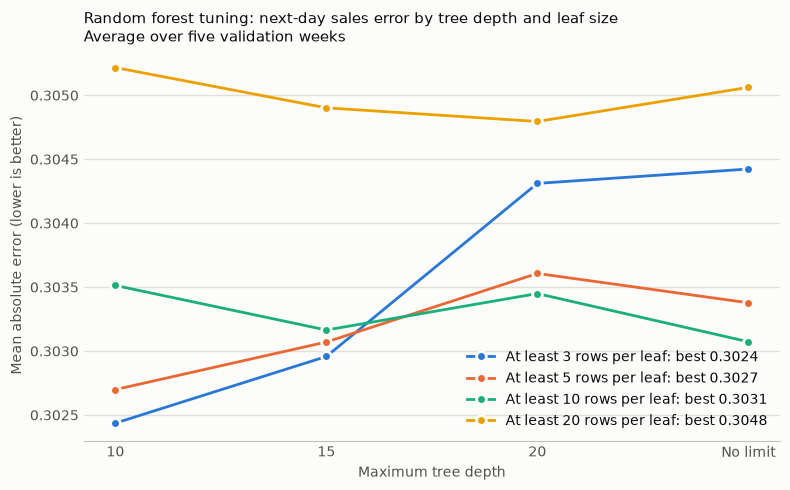

In [12]:
RF_DEPTHS, RF_LEAVES = ["10", "15", "20", "No limit"], [3, 5, 10, 20]
RF_GRID = [{"max_depth": d, "min_leaf": l} for d in RF_DEPTHS for l in RF_LEAVES]

if RERUN_TUNING:
    rf_folds = ev.cross_validate(feat, models.make_rf, RF_GRID, n_jobs=1, describe=models.tree_depth)
    rf_folds.to_csv(C.RESULTS / "rf_tuning_folds.csv", index=False)
else:
    rf_folds = pd.read_csv(C.RESULTS / "rf_tuning_folds.csv", dtype={"max_depth": str})

rf_summary = ev.summarise(rf_folds, ["max_depth", "min_leaf"], baseline, extra={"deepest_tree": ("actual_depth", "max")})
display(rf_summary.mae.unstack("min_leaf").reindex(RF_DEPTHS).round(4))
display(rf_summary.deepest_tree.unstack("min_leaf").reindex(RF_DEPTHS))

fig = plots.plot_rf_tuning(rf_summary, RF_DEPTHS, RF_LEAVES, save=C.RESULTS / "rf_tuning.png")

- The whole grid spans 0.003, about a seventh of the week-to-week variation (0.02). The plot's vertical axis covers only that range, so the lines look further apart than they are.
- Depth and leaf size trade off: with small leaves a depth cap helps slightly; with leaves of 10 it makes no difference.
- Without a limit, trees grow to 27–41 levels depending on leaf size.

### Further checks (one-off runs, change against 0.3024)

| Setting | Value tried | MAE |
|---|---|---|
| Random seed | Four other seeds | 0.3026–0.3028 |
| Number of trees | 50 / 100 / 1,000 | 0.3040 / 0.3028 / 0.3025 |
| Shallower depth | 4 / 6 / 8 | 0.3230 / 0.3087 / 0.3040 |
| Features tried per split | A third / three quarters / all | 0.3037 / 0.3030 / 0.3048 |
| Rows sampled per tree | Half / three quarters | 0.3017 / 0.3023 |
| Split rule | Absolute error (100 trees) | 0.3019 |
| Target | Sales ÷ 7-day average | 0.3033 |
| Tree type | Extra-trees variant | 0.3069 |

- Depth 10 is a real minimum: depths 8, 6 and 4 are progressively worse.
- 300 trees is enough. Seed noise is about 0.0004; no alternative improves on the chosen design by more than 0.001.

### Locked random forest design

- 10 features, no scaling
- **300 trees, maximum depth 10, at least 3 rows per leaf**
- Half the features tried at each split, squared-error splits

In [13]:
RF_DEPTH, RF_LEAF = "10", 3
rf_val = rf_folds[(rf_folds.max_depth == RF_DEPTH) & (rf_folds.min_leaf == RF_LEAF)].set_index("fold")
display(pd.DataFrame({"Random forest": rf_val[["mae", "wape", "mse"]].mean(), "kNN": knn_val[["mae", "wape", "mse"]].mean(),
                      "Baseline": baseline.mean()}).T.round(3))

,mae,wape,mse
Random forest,0.302,0.317,0.219
kNN,0.312,0.327,0.237
Baseline,0.328,0.345,0.270


## 10. CatBoost (next model to test)

**How it works.** Gradient boosting builds trees one after another, each one fitted to the errors left by the trees before it, with a learning rate that controls how much each new tree corrects. Unlike the forest, the trees are shallow and the sequence *is* a training loop, so there is a loss curve to look at. CatBoost is a boosting library with sensible defaults, symmetric trees and built-in protection against over-fitting on small data.

**Plan.** Same 10 features, same five folds, same baseline. Settings to tune: tree depth, learning rate and the number of trees (iterations), then the loss function (RMSE against MAE). `models.make_catboost` is the factory; the cell below is the starting grid, switched off until the tuning is run.

In [14]:
TUNE_CATBOOST = False  # flip to True to run the first CatBoost grid (a few minutes)

CATBOOST_GRID = [{"depth": d, "learning_rate": lr, "iterations": 500} for d in (4, 6, 8) for lr in (0.03, 0.1)]

if TUNE_CATBOOST:
    cat_folds = ev.cross_validate(feat, models.make_catboost, CATBOOST_GRID, n_jobs=1)
    cat_folds.to_csv(C.RESULTS / "catboost_tuning_folds.csv", index=False)
    cat_summary = ev.summarise(cat_folds, ["depth", "learning_rate", "iterations"], baseline)
    display(cat_summary.round(4))
else:
    print("CatBoost tuning not run yet. Set TUNE_CATBOOST = True.")

CatBoost tuning not run yet. Set TUNE_CATBOOST = True.


## 11. Ensemble of random forest and CatBoost (next model to test)

**Idea.** The forest and the boosted trees make different kinds of errors: the forest averages many deep, independent trees; boosting stacks shallow, dependent ones. Averaging their predictions can cancel some of each model's noise. `models.make_ensemble` wraps both in a scikit-learn `VotingRegressor`; the weights can be tuned once CatBoost's design is locked.

In [15]:
TUNE_ENSEMBLE = False  # requires a locked CatBoost design first

if TUNE_ENSEMBLE:
    ENSEMBLE_GRID = [{"weights": w} for w in ([1, 1], [2, 1], [1, 2])]
    make = lambda weights: models.make_ensemble([("rf", models.make_rf()), ("catboost", models.make_catboost())], weights=weights)
    ens_folds = ev.cross_validate(feat, make, ENSEMBLE_GRID, n_jobs=1)
    ens_folds["weights"] = ens_folds.weights.astype(str)
    display(ev.summarise(ens_folds, ["weights"], baseline).round(4))
else:
    print("Ensemble tuning not run yet. Set TUNE_ENSEMBLE = True after locking CatBoost.")

Ensemble tuning not run yet. Set TUNE_ENSEMBLE = True after locking CatBoost.


## 12. Model comparison

### Validation weeks

Each locked model against the baseline in every validation week. To add a model, add its per-fold MAE to `validation_mae` and its colour to `colours`.

,Baseline (7-day average),kNN (k = 25),"Random forest (depth 10, leaf ≥ 3)"
fold,,,
May 22–28,0.309,0.295,0.290
May 29–Jun 4,0.316,0.299,0.291
Jun 5–11,0.362,0.350,0.336
Jun 12–18,0.327,0.301,0.290
Jun 19–25,0.328,0.316,0.306


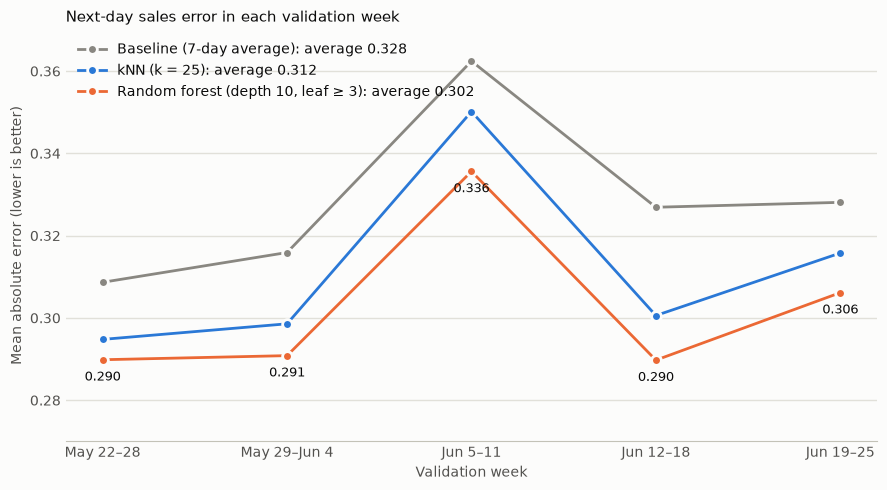

In [16]:
validation_mae = pd.DataFrame({
    "Baseline (7-day average)": baseline.mae,
    f"kNN (k = {KNN_K})": knn_val.mae,
    f"Random forest (depth {RF_DEPTH}, leaf ≥ {RF_LEAF})": rf_val.mae,
})
colours = dict(zip(validation_mae.columns, [C.COLOURS["baseline"], C.COLOURS["knn"], C.COLOURS["rf"]]))

display(validation_mae.rename(index=C.FOLD_LABELS).round(3))
fig = plots.plot_validation_weeks(validation_mae, colours, annotate=validation_mae.columns[-1], save=C.RESULTS / "validation_weeks.png")

The order is the same in every week: random forest, then kNN, then the baseline.

### The unseen test week (June 26 – July 2)

Each locked model is fitted once on all training rows (April 4 – June 25) and scored on the test week. This is the honest number: every design choice above was made without looking at it.

In [17]:
test, fitted = ev.fit_predict_test(feat, {"knn": models.make_knn(KNN_K), "rf": models.make_rf(max_depth=RF_DEPTH, min_leaf=RF_LEAF)})
methods = {"Random forest": "pred_rf", "kNN (k=25)": "pred_knn", "Baseline (7-day mean)": "pred_baseline", "Same weekday last week": "pred_same_weekday"}

print(f"train rows: {len(ev.training_rows(feat)):,}   test rows: {len(test):,}")
overall = ev.score_methods(test, methods)
display(overall.round(4))

overall.to_csv(C.RESULTS / "test_summary.csv")
test[C.ROW_KEY + ["discount_next", C.TARGET, "target_stockout_hours", *methods.values()]].to_csv(C.RESULTS / "test_predictions.csv", index=False)

train rows: 25,896   test rows: 2,184


,mae,wape,mse,rmse
Random forest,0.2923,0.3018,0.2158,0.4646
kNN (k=25),0.3040,0.3138,0.2401,0.4900
Baseline (7-day mean),0.3142,0.3244,0.2713,0.5209
Same weekday last week,0.3998,0.4127,0.3808,0.6171


- Random forest against the baseline: MAE 7.0% lower, MSE 20.5% lower. Its validation lead over the baseline was 7.9% on MAE, so nearly all of it carried over.
- kNN against the baseline: MAE 3.2% lower, MSE 11.5% lower. The validation gap was 5%, so about a third did not carry over.

### By tomorrow's discount

The days that matter for phase 2 are the discounted ones.

In [18]:
print("MAE by tomorrow's discount")
display(ev.mae_by(test, methods, test.discount_band).round(3))
print("\nMean sales by tomorrow's discount: actual and predicted")
display(ev.mean_by(test, methods, test.discount_band).round(3))

MAE by tomorrow's discount


,Random forest,kNN (k=25),Baseline (7-day mean),Same weekday last week,rows
discount_band,,,,,
deep (below 0.8),0.546,0.581,0.561,0.659,241
moderate (0.8-0.95),0.301,0.309,0.303,0.380,757
none (0.95-1.0),0.235,0.245,0.271,0.360,1186



Mean sales by tomorrow's discount: actual and predicted


,target_sales,pred_rf,pred_knn,pred_baseline,pred_same_weekday
discount_band,,,,,
deep (below 0.8),1.659,1.567,1.495,1.391,1.318
moderate (0.8-0.95),0.997,1.027,0.987,0.998,1.009
none (0.95-1.0),0.810,0.816,0.805,0.887,0.912


- The forest beats the baseline on deep-discount days, where kNN does not, and comes closest to the actual spike.
- On moderate discounts the forest is level with the baseline.
- Errors on deep-discount days are more than twice those on ordinary days for every method. Every model still under-predicts the deep-discount spike.

### By day and by store

In [19]:
print("MAE by day")
display(ev.mae_by(test, methods, test.dt.dt.strftime("%m-%d %a")).round(3))
print("\nMAE by store")
display(ev.mae_by(test, methods, test.store_id).round(3))

MAE by day


,Random forest,kNN (k=25),Baseline (7-day mean),Same weekday last week,rows
dt,,,,,
06-26 Wed,0.282,0.287,0.315,0.395,312
06-27 Thu,0.247,0.267,0.279,0.371,312
06-28 Fri,0.286,0.285,0.283,0.380,312
06-29 Sat,0.330,0.347,0.342,0.456,312
06-30 Sun,0.348,0.359,0.403,0.463,312
07-01 Mon,0.265,0.272,0.276,0.319,312
07-02 Tue,0.287,0.311,0.300,0.414,312



MAE by store


,Random forest,kNN (k=25),Baseline (7-day mean),Same weekday last week,rows
store_id,,,,,
18,0.295,0.310,0.313,0.397,448
154,0.261,0.261,0.258,0.326,420
182,0.293,0.300,0.329,0.411,427
235,0.286,0.301,0.310,0.394,441
343,0.326,0.345,0.358,0.467,448


### What the forest relies on

In [20]:
display(models.feature_importance(fitted["rf"]).round(3).to_frame("importance"))

,importance
sales_mean7,0.434
sales_mean_to_date,0.209
sales_t,0.139
discount_next,0.105
sales_lag7,0.059
discount_t,0.021
weekday_next,0.015
stockout_hours_t,0.008
holiday_next,0.008
activity_t,0.002


Sales history sets the level; tomorrow's discount is the main driver of the change. This matches the kNN feature-removal test.

### Summary figure

,Random forest,kNN (k=25),Baseline (7-day mean)
Validation\n(5-week average),0.302,0.312,0.328
Test week\n(all rows),0.292,0.304,0.314
"Test: no discount\n(1,186 rows)",0.235,0.245,0.271
Test: moderate discount\n(757 rows),0.301,0.309,0.303
Test: deep discount\n(241 rows),0.546,0.581,0.561


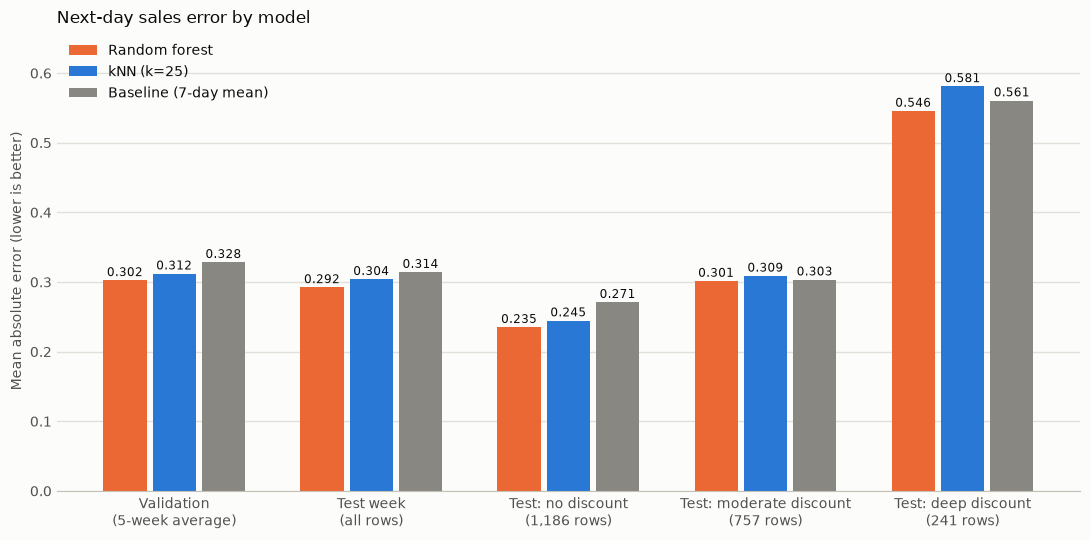

In [21]:
compare = {label: col for label, col in methods.items() if col != "pred_same_weekday"}
validation_avg = {"Baseline (7-day mean)": baseline.mae.mean(), "kNN (k=25)": knn_val.mae.mean(), "Random forest": rf_val.mae.mean()}
fig, table = plots.plot_model_comparison(validation_avg, test, compare,
                                         {"Baseline (7-day mean)": C.COLOURS["baseline"], "kNN (k=25)": C.COLOURS["knn"], "Random forest": C.COLOURS["rf"]},
                                         save=C.RESULTS / "model_comparison.png")
display(table.round(3))

## 13. Findings and limits

1. **Success test met by both models.** kNN and the random forest beat the 7-day average on validation and on the unseen week.
2. **The random forest is the best model so far.** It leads kNN and the baseline in every validation week and on the test week, and its lead held from validation to test (7.9% to 7.0% on MAE).
3. **Feature choice mattered more than any setting.** Removing weather was the largest single gain for both models; k, distance measure, depth and leaf size were all within week-to-week noise once it was gone.
4. **Prior expectations were partly wrong.** Weather and stockout hours did not help; sales history and tomorrow's discount did.
5. **Better on the days that matter.** The forest is the only model ahead of the baseline on deep-discount days, which makes it the better engine for phase 2. kNN averages 25 neighbours and is pulled towards typical sales.
6. **Still under-predicts deep discounts.** 1.57 against an actual 1.66, and errors there are more than twice the ordinary-day error. No edge on moderate discounts.
7. **Selection optimism.** Many options were compared on the same five weeks, so validation figures are slightly flattering. The test week is the honest number.
8. **Scope.** Five stores in one city, one unseen week. Results may not carry to other cities or seasons.
9. **Phase 2 caveats.** Discounts were not assigned at random, so the response is correlational; and choosing an "optimal" discount needs a margin assumption, since the model predicts volume only.

## 14. Next steps

1. Tune CatBoost on the same folds (section 10) and lock a design.
2. Tune the forest + CatBoost ensemble (section 11).
3. Add both to the comparison in section 12 and pick the best model on the test week.
4. Phase 2: feed candidate discounts into the chosen model to suggest a discount per store-product.

## Appendix: reproducing this notebook

| Where | What |
|---|---|
| `src/finalproject_pricingml/data.py` | Series selection, cleaning, features, splits |
| `src/finalproject_pricingml/evaluate.py` | Metrics, time-ordered cross-validation, test-week scoring |
| `src/finalproject_pricingml/models.py` | One factory per model: kNN, random forest, CatBoost, ensemble |
| `src/finalproject_pricingml/plots.py` | The figures |
| `results/` | Every tuning grid and test-week prediction as CSV, plus the figures |
| `docs/` | The original build-out notes for kNN and the random forest |

Set `RERUN_TUNING = True` in the first cell to recompute every grid from scratch. The one-off checks quoted in sections 6, 8 and 9 were run interactively and are not scripted.